# Problem Statement

To build a machine learning model that can accurately predict the presence or absence of heart disease in a patient 
based on clinical and physiological attributes using the K-Nearest Neighbors (KNN) classification algorithm.

# Import Libraries

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV  # Hyperparameyer tuning

from sklearn.preprocessing import MinMaxScaler, StandardScaler  #Feature Scaling

from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Read dataset

In [2]:
df = pd.read_csv('KNN_class_heart.csv')
df

,age,gender,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


# Basic Checks

In [3]:
df.head()

,age,gender,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
df.tail()

,age,gender,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   gender    303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


i)there are total 13 features and target as a target column
ii)all are numerical columns and label encoded

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
gender,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


i)there are records of age between 29 to 77
ii)this data is small and quitly cleaned

# Domain Analysis

age :-	Patient’s age

sex	:- Gender of the patient (0 = female, 1 = male)

cp :-	Chest pain type (categorical: 0–3)

trestbps :-	Resting blood pressure (in mm Hg)

chol :-	Serum cholesterol in mg/dl

fbs :-	Fasting blood sugar > 120 mg/dl (1 = true; 0 = false)

restecg :-	Resting electrocardiographic results (categorical)

thalach :-	Maximum heart rate achieved

exang :-	Exercise induced angina (1 = yes; 0 = no)

oldpeak	:- ST depression induced by exercise relative to rest

slope :-	Slope of the peak exercise ST segment

ca :-	Number of major vessels (0–3) colored by fluoroscopy

thal :-	A blood disorder: normal (3), fixed defect (6), or reversible defect (7)

target :-	Presence (1) or absence (0) of heart disease (your predicted output)

# EDA

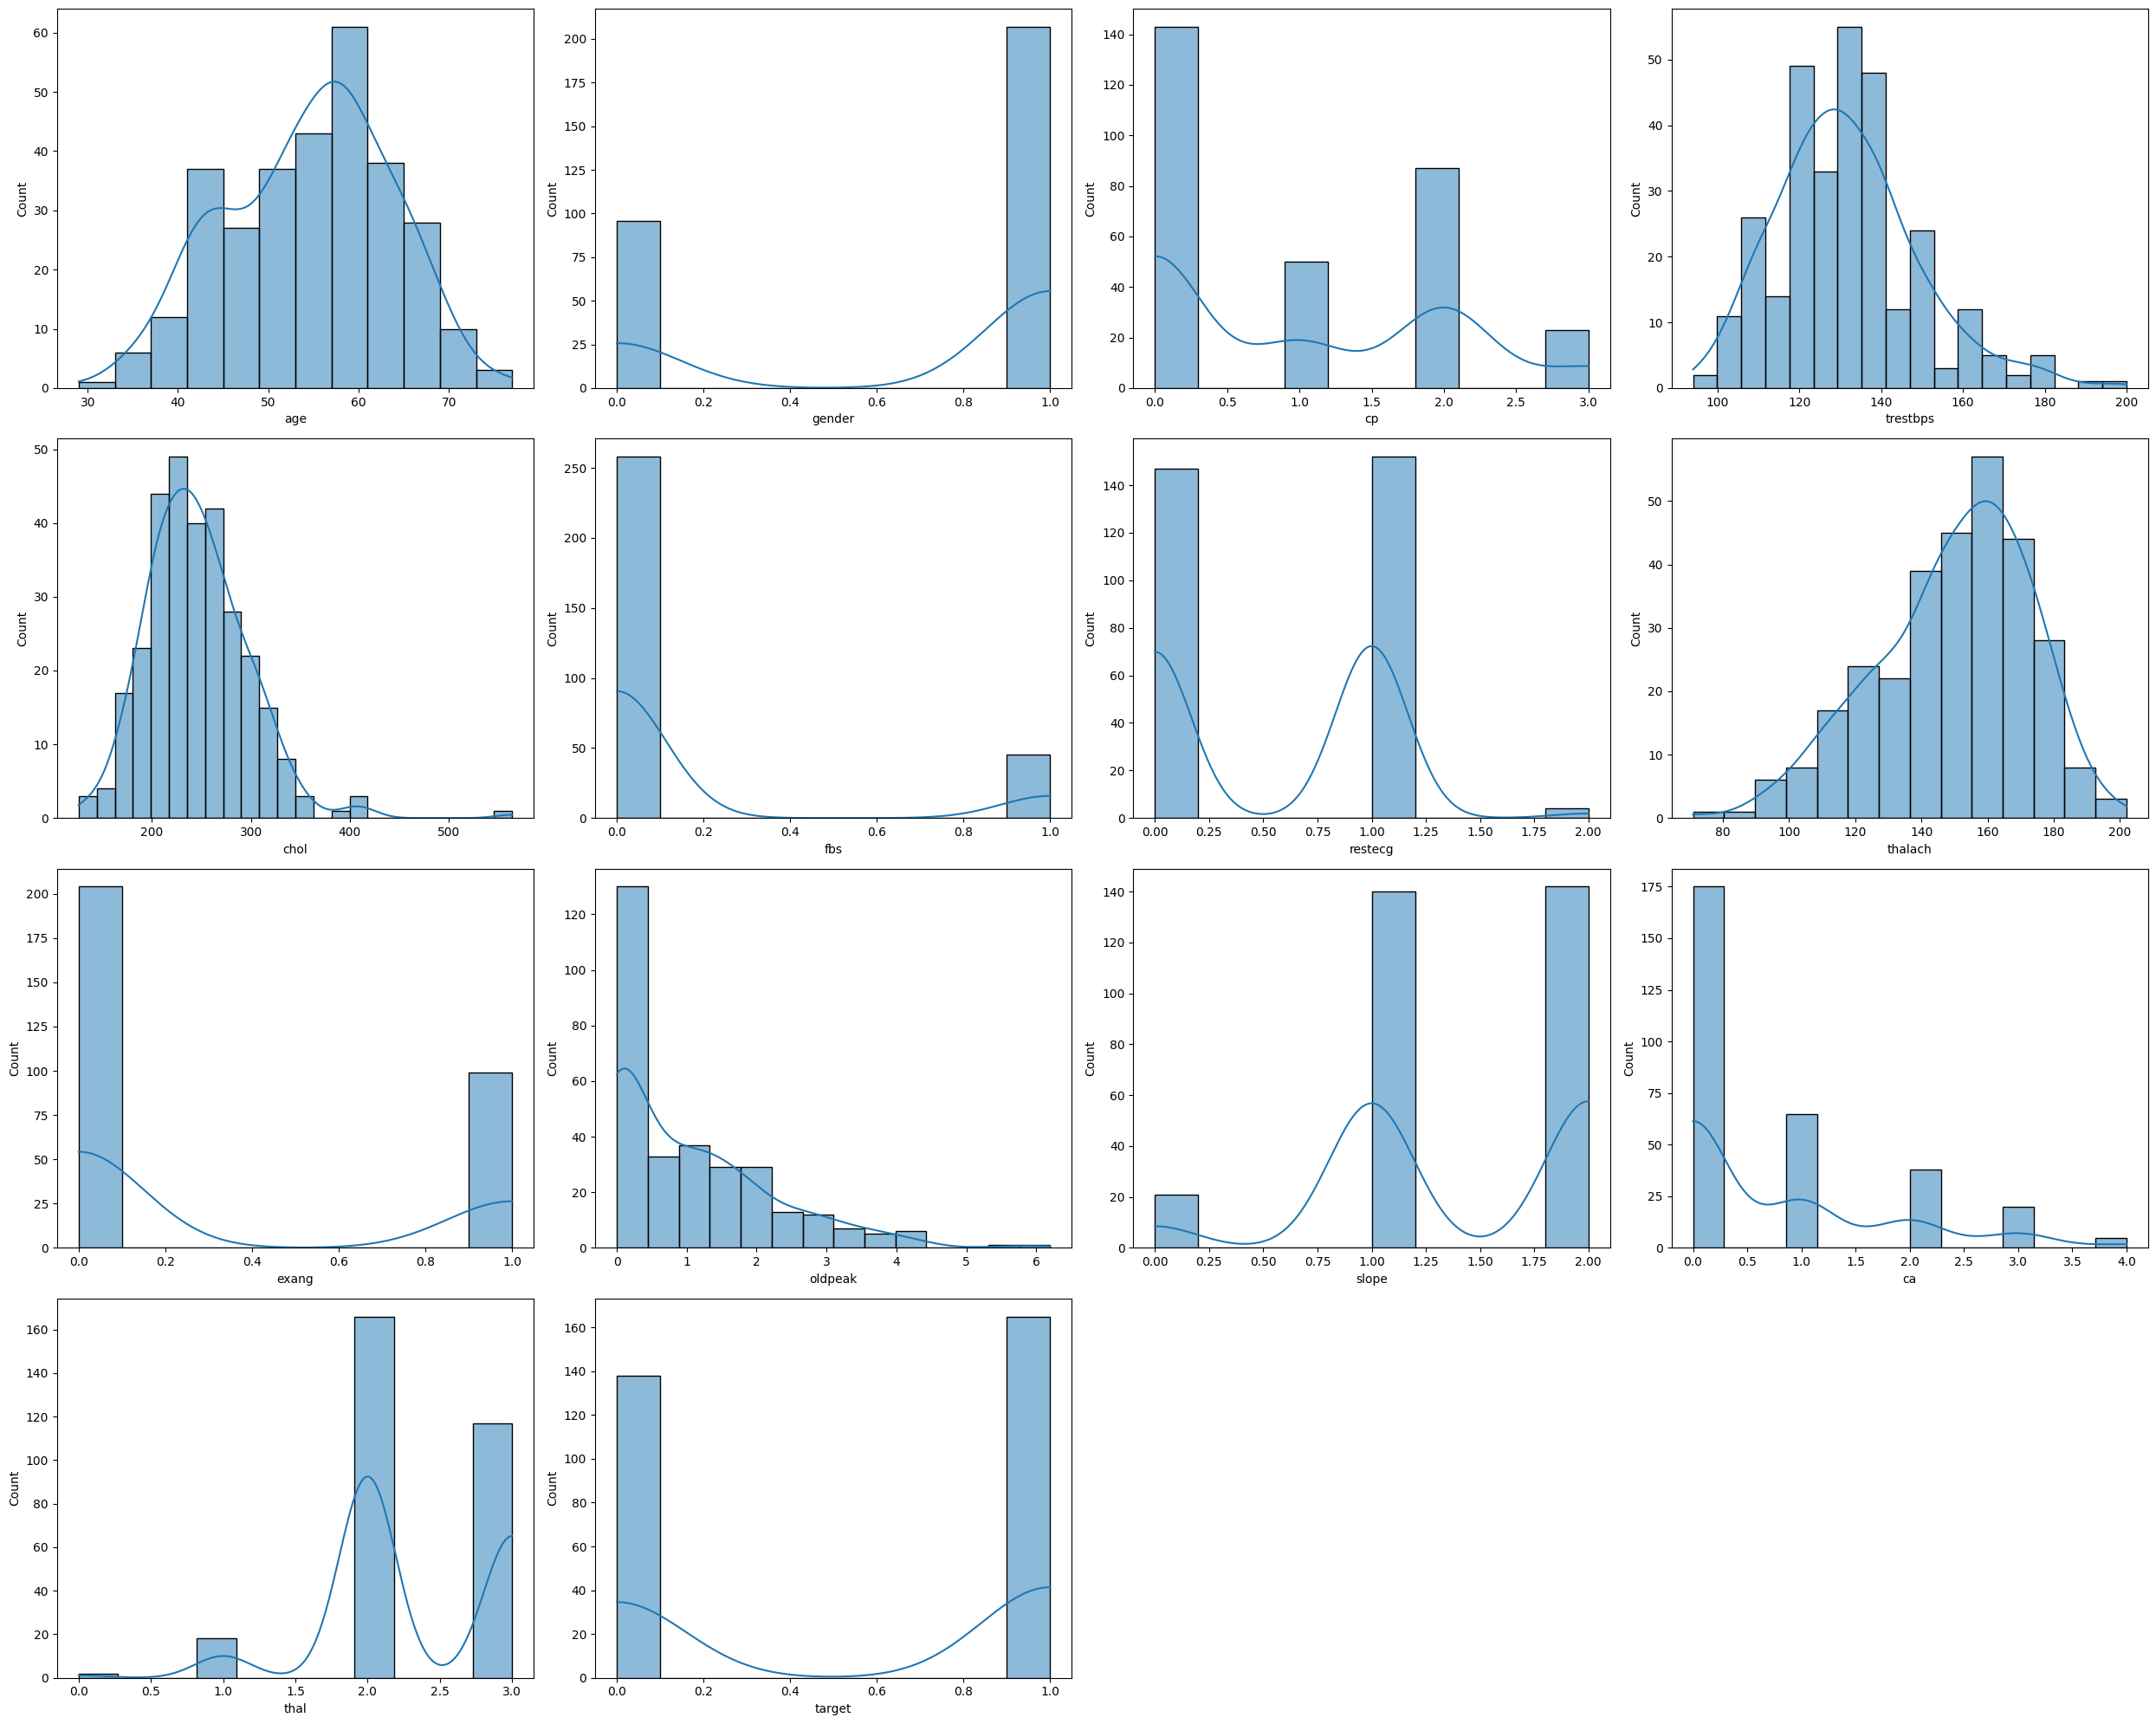

In [9]:
plotn=1
plt.figure(figsize=(25,20))
for i in df.columns:
    if plotn<=14:
        ax=plt.subplot(4,4,plotn)
        sns.histplot(x=df[i],data=df,kde=True)
    plotn+=1
plt.tight_layout()
plt.show()

# Data Preprocessing

In [10]:
df.isna().sum()

age         0
gender      0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [12]:
#there are no null values

In [11]:
df.duplicated().sum()

1

In [13]:
#only 1 duolicated value so no need to handle it

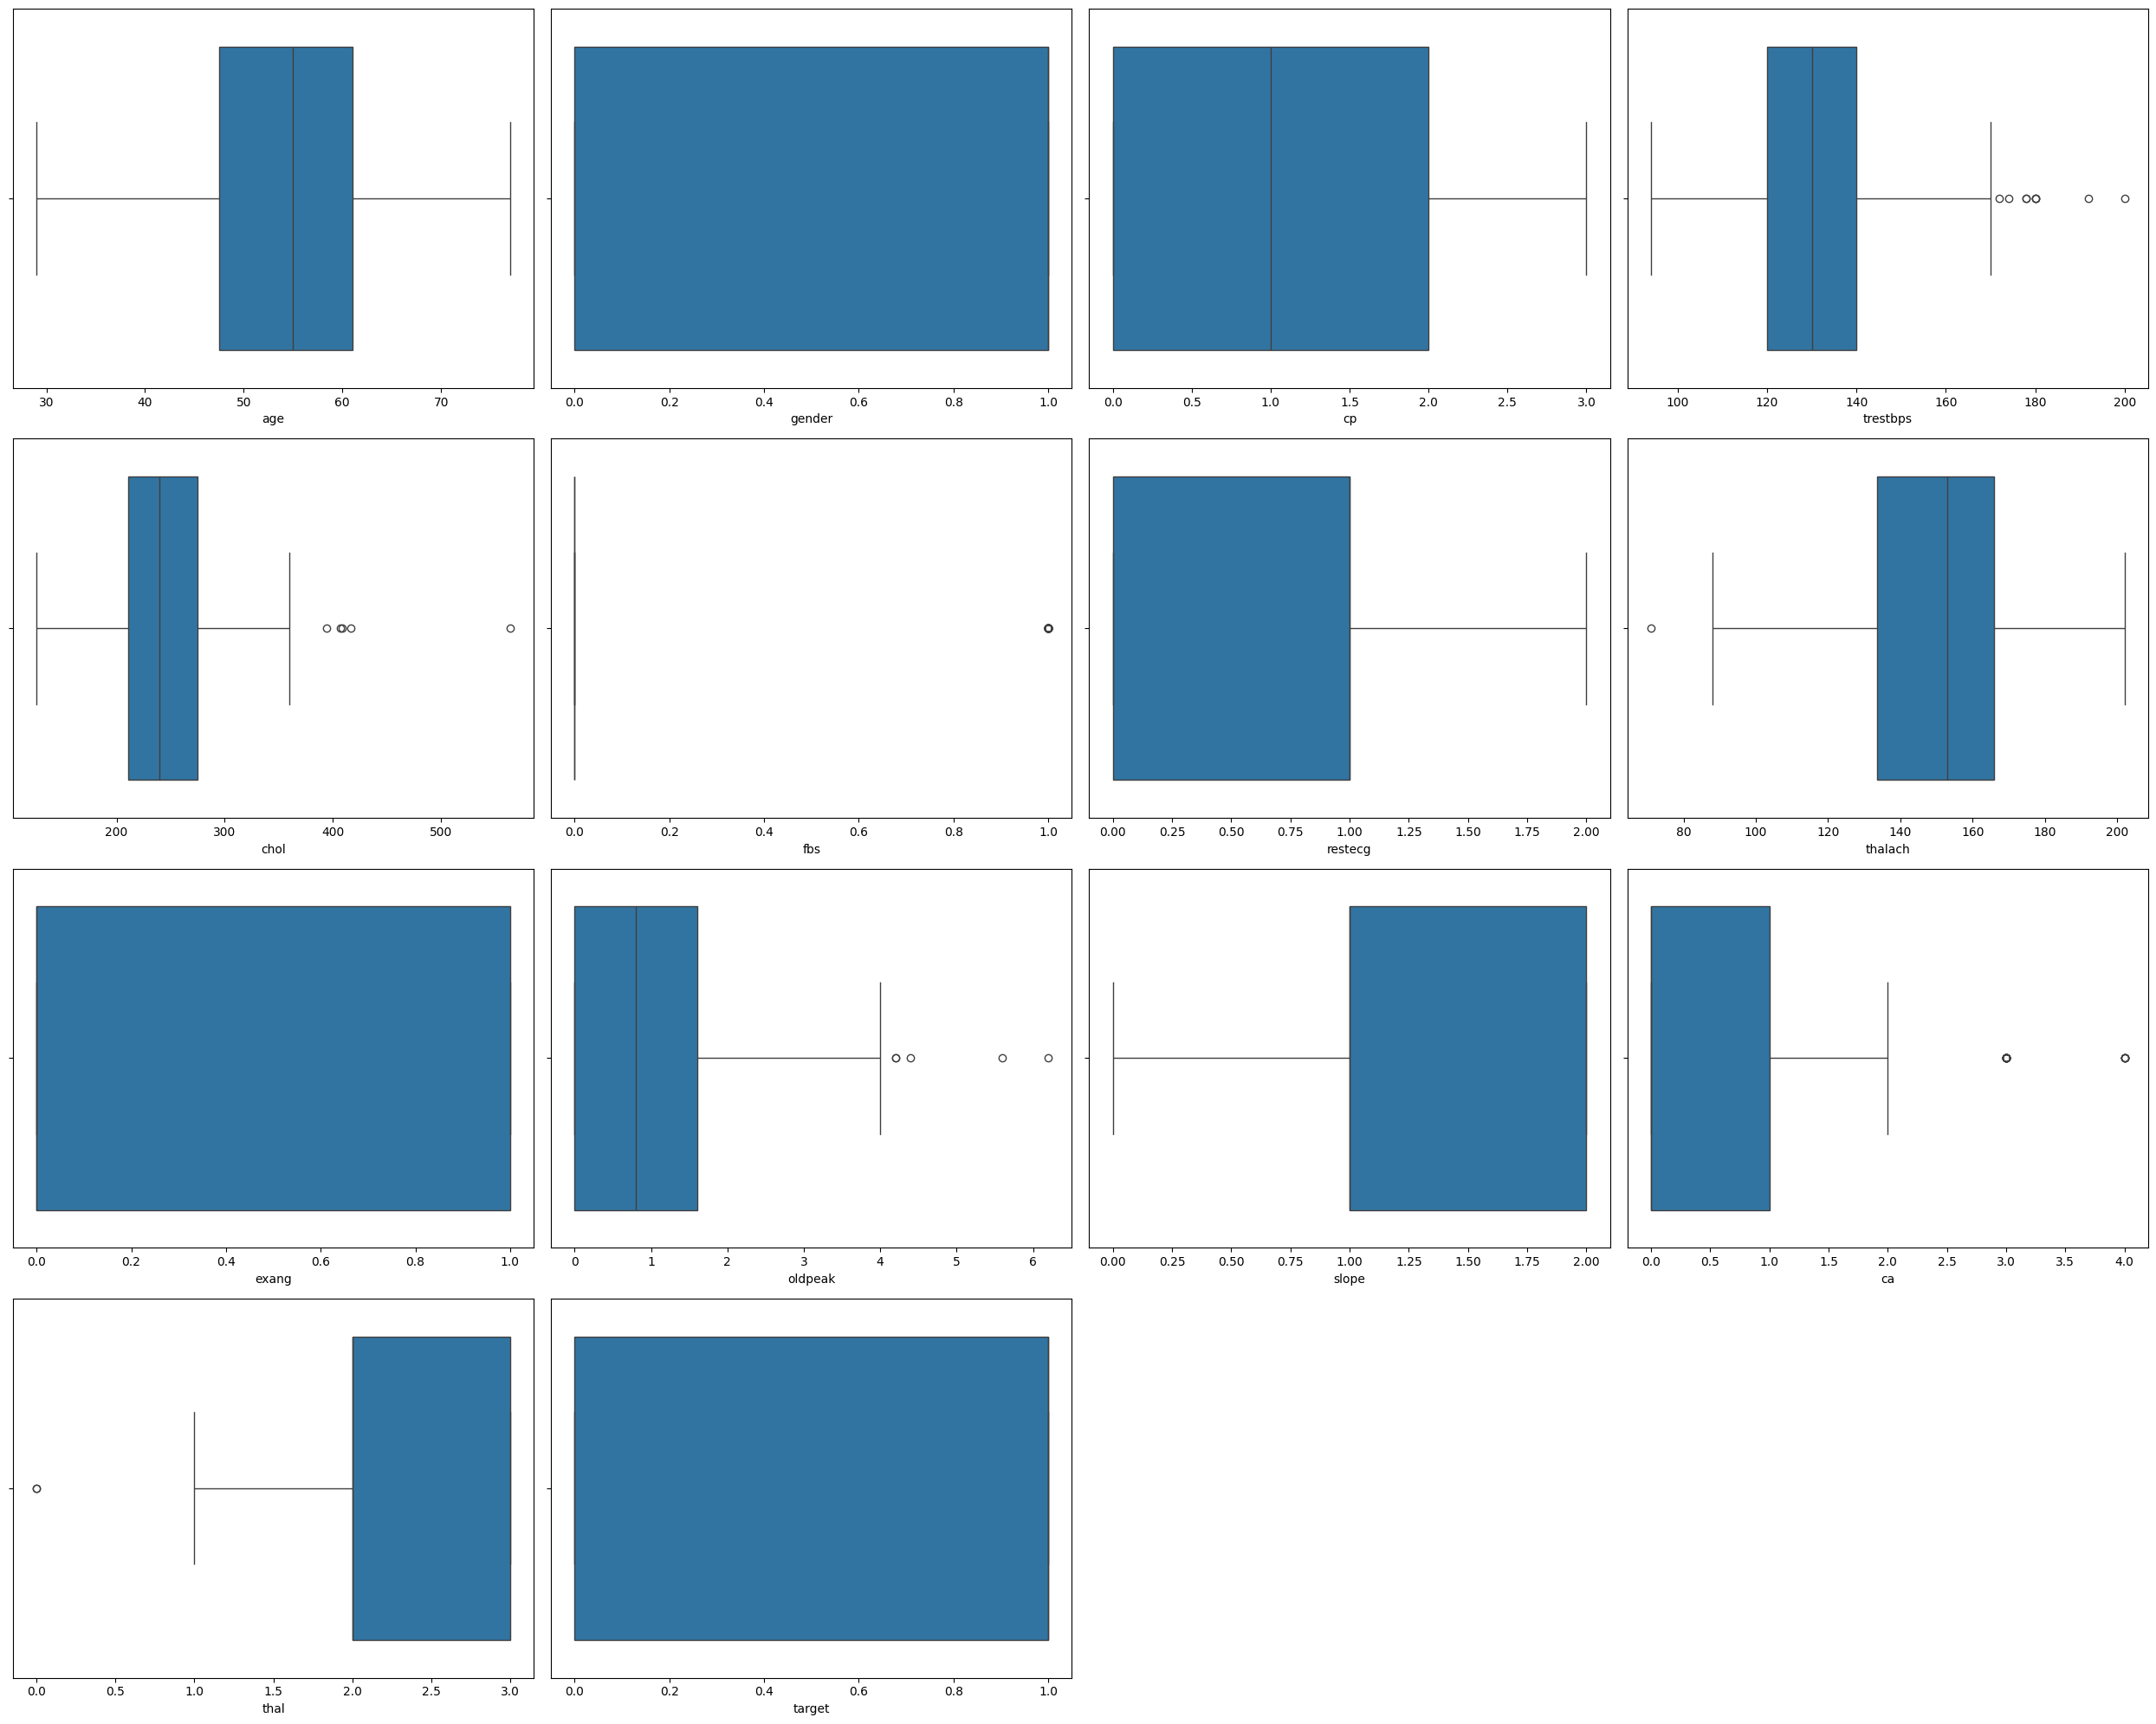

In [15]:
plotn=1
plt.figure(figsize=(25,20))
for i in df.columns:
    if plotn<=14:
        ax=plt.subplot(4,4,plotn)
        sns.boxplot(x=df[i],data=df)
    plotn+=1
plt.tight_layout()
plt.show()

In [16]:
#in this some are encoded categorical columns so the outliers represented by graph are not outliers they are values in that range 

# Feature Engineering

<Axes: >

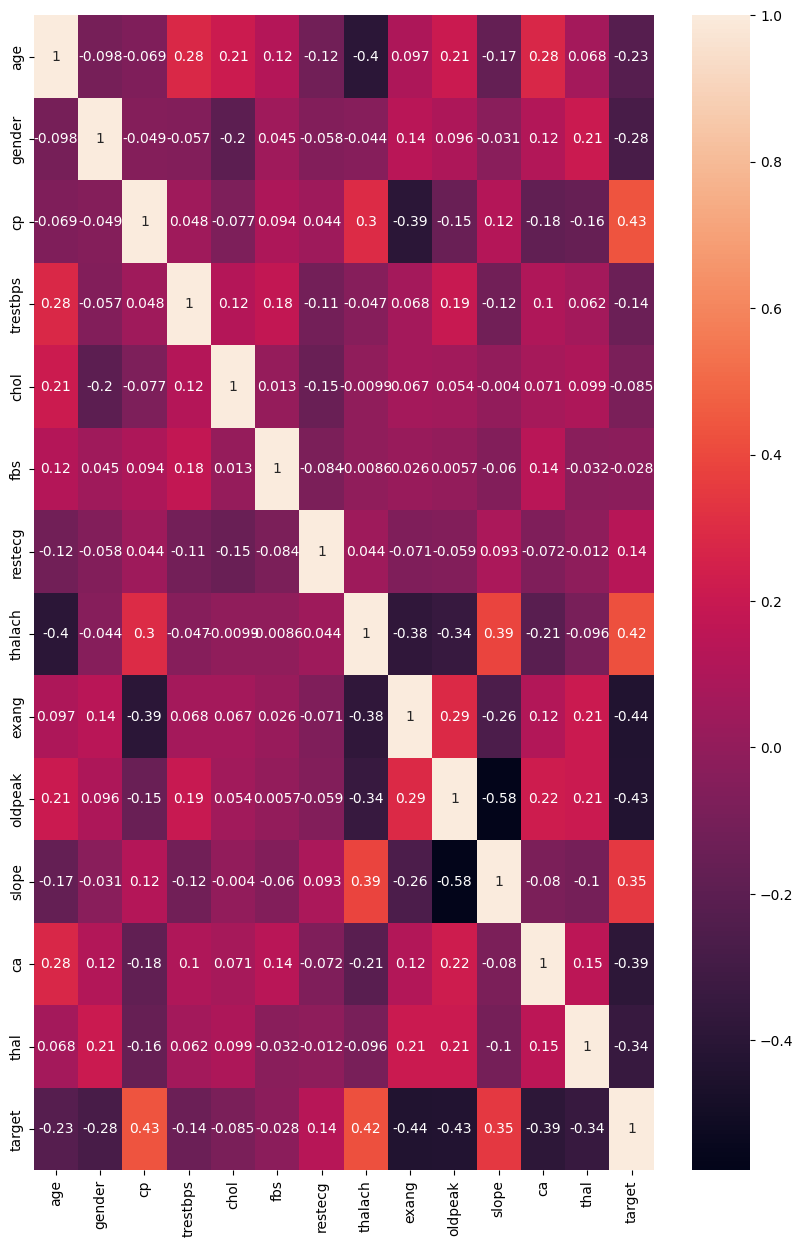

In [24]:
plt.figure(figsize=(10,15))
sns.heatmap(df.corr(),annot=True)

In [25]:
#there are no columns having correalation <0.9 and -0.9<

In [26]:
X = df.drop('target', axis=1)
y = df['target']

#### MinMax Scaler (Normalization)

In [27]:
# Create instance of MInMax Scaler (Normalization)
minmax_scaler = MinMaxScaler()
X_scaled = minmax_scaler.fit_transform(X)
# X_scaled
X_minmax_df = pd.DataFrame(X_scaled, columns=X.columns)
X_minmax_df

,age,gender,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,0.708333,1.0,1.000000,0.481132,0.244292,1.0,0.0,0.603053,0.0,0.370968,0.0,0.00,0.333333
1,0.166667,1.0,0.666667,0.339623,0.283105,0.0,0.5,0.885496,0.0,0.564516,0.0,0.00,0.666667
2,0.250000,0.0,0.333333,0.339623,0.178082,0.0,0.0,0.770992,0.0,0.225806,1.0,0.00,0.666667
3,0.562500,1.0,0.333333,0.245283,0.251142,0.0,0.5,0.816794,0.0,0.129032,1.0,0.00,0.666667
4,0.583333,0.0,0.000000,0.245283,0.520548,0.0,0.5,0.702290,1.0,0.096774,1.0,0.00,0.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,0.583333,0.0,0.000000,0.433962,0.262557,0.0,0.5,0.396947,1.0,0.032258,0.5,0.00,1.000000
299,0.333333,1.0,1.000000,0.150943,0.315068,0.0,0.5,0.465649,0.0,0.193548,0.5,0.00,1.000000
300,0.812500,1.0,0.000000,0.471698,0.152968,1.0,0.5,0.534351,0.0,0.548387,0.5,0.50,1.000000
301,0.583333,1.0,0.000000,0.339623,0.011416,0.0,0.5,0.335878,1.0,0.193548,0.5,0.25,1.000000


In [28]:
# X.columns

In [29]:
X_minmax_df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,0.528465,0.189210,0.0,0.385417,0.541667,0.666667,1.0
gender,303.0,0.683168,0.466011,0.0,0.000000,1.000000,1.000000,1.0
cp,303.0,0.322332,0.344017,0.0,0.000000,0.333333,0.666667,1.0
trestbps,303.0,0.354941,0.165454,0.0,0.245283,0.339623,0.433962,1.0
chol,303.0,0.274575,0.118335,0.0,0.194064,0.260274,0.339041,1.0
fbs,303.0,0.148515,0.356198,0.0,0.000000,0.000000,0.000000,1.0
restecg,303.0,0.264026,0.262930,0.0,0.000000,0.500000,0.500000,1.0
thalach,303.0,0.600358,0.174849,0.0,0.477099,0.625954,0.725191,1.0
exang,303.0,0.326733,0.469794,0.0,0.000000,0.000000,1.000000,1.0
oldpeak,303.0,0.167678,0.187270,0.0,0.000000,0.129032,0.258065,1.0


#### Standrad Scaler (Standradization)

In [30]:
std_scaler = StandardScaler()
X_scaled = std_scaler.fit_transform(X)
# X_scaled
X_std_df = pd.DataFrame(X_scaled, columns=X.columns)
X_std_df

,age,gender,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,0.952197,0.681005,1.973123,0.763956,-0.256334,2.394438,-1.005832,0.015443,-0.696631,1.087338,-2.274579,-0.714429,-2.148873
1,-1.915313,0.681005,1.002577,-0.092738,0.072199,-0.417635,0.898962,1.633471,-0.696631,2.122573,-2.274579,-0.714429,-0.512922
2,-1.474158,-1.468418,0.032031,-0.092738,-0.816773,-0.417635,-1.005832,0.977514,-0.696631,0.310912,0.976352,-0.714429,-0.512922
3,0.180175,0.681005,0.032031,-0.663867,-0.198357,-0.417635,0.898962,1.239897,-0.696631,-0.206705,0.976352,-0.714429,-0.512922
4,0.290464,-1.468418,-0.938515,-0.663867,2.082050,-0.417635,0.898962,0.583939,1.435481,-0.379244,0.976352,-0.714429,-0.512922
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,0.290464,-1.468418,-0.938515,0.478391,-0.101730,-0.417635,0.898962,-1.165281,1.435481,-0.724323,-0.649113,-0.714429,1.123029
299,-1.033002,0.681005,1.973123,-1.234996,0.342756,-0.417635,0.898962,-0.771706,-0.696631,0.138373,-0.649113,-0.714429,1.123029
300,1.503641,0.681005,-0.938515,0.706843,-1.029353,2.394438,0.898962,-0.378132,-0.696631,2.036303,-0.649113,1.244593,1.123029
301,0.290464,0.681005,-0.938515,-0.092738,-2.227533,-0.417635,0.898962,-1.515125,1.435481,0.138373,-0.649113,0.265082,1.123029


In [31]:
X_std_df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,4.690051e-17,1.001654,-2.797624,-0.757280,0.069886,0.731619,2.496240
gender,303.0,-1.407015e-16,1.001654,-1.468418,-1.468418,0.681005,0.681005,0.681005
cp,303.0,2.345026e-17,1.001654,-0.938515,-0.938515,0.032031,1.002577,1.973123
trestbps,303.0,-7.035077e-16,1.001654,-2.148802,-0.663867,-0.092738,0.478391,3.905165
chol,303.0,-1.113887e-16,1.001654,-2.324160,-0.681494,-0.121055,0.545674,6.140401
fbs,303.0,-2.345026e-17,1.001654,-0.417635,-0.417635,-0.417635,-0.417635,2.394438
restecg,303.0,1.465641e-16,1.001654,-1.005832,-1.005832,0.898962,0.898962,2.803756
thalach,303.0,-6.800574e-16,1.001654,-3.439267,-0.706111,0.146634,0.715131,2.289429
exang,303.0,-4.690051e-17,1.001654,-0.696631,-0.696631,-0.696631,1.435481,1.435481
oldpeak,303.0,2.345026e-17,1.001654,-0.896862,-0.896862,-0.206705,0.483451,4.451851


# Train Test Split

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X_minmax_df, y,test_size=0.20, random_state=42)

In [33]:
X_test

,age,gender,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
179,0.583333,1.0,0.000000,0.528302,0.342466,0.0,0.0,0.312977,1.0,0.096774,0.5,0.25,0.333333
228,0.625000,1.0,1.000000,0.716981,0.369863,0.0,0.0,0.671756,0.0,0.032258,0.5,0.00,1.000000
111,0.583333,1.0,0.666667,0.528302,0.000000,1.0,0.5,0.778626,0.0,0.032258,1.0,0.25,1.000000
246,0.562500,0.0,0.000000,0.377358,0.646119,0.0,0.0,0.603053,1.0,0.306452,0.5,0.50,1.000000
60,0.875000,0.0,0.666667,0.150943,0.317352,1.0,0.0,0.450382,0.0,0.000000,1.0,0.25,0.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...
249,0.833333,1.0,0.666667,0.433962,0.292237,0.0,0.0,0.572519,0.0,0.322581,0.5,0.75,1.000000
104,0.437500,1.0,0.666667,0.330189,0.159817,0.0,0.5,0.702290,0.0,0.000000,1.0,0.00,0.666667
300,0.812500,1.0,0.000000,0.471698,0.152968,1.0,0.5,0.534351,0.0,0.548387,0.5,0.50,1.000000
193,0.645833,1.0,0.000000,0.481132,0.356164,0.0,0.0,0.541985,1.0,0.451613,0.5,0.50,1.000000


### Train Model

In [34]:
knn_class = KNeighborsClassifier(n_neighbors=5, p=2)
knn_class.fit(X_train, y_train)

KNeighborsClassifier()

In [35]:
y_pred = knn_class.predict(X_test)
y_pred

array([0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0], dtype=int64)

In [36]:
y_test[:5]

179    0
228    0
111    1
246    0
60     1
Name: target, dtype: int64

In [37]:
y_pred[:5]

array([0, 1, 1, 0, 1], dtype=int64)

# Evaluation

In [38]:
#Confusion Matrix
con_matrix = confusion_matrix(y_test, y_pred)
con_matrix

array([[25,  4],
       [ 7, 25]], dtype=int64)

In [39]:
from sklearn.metrics import precision_score

In [40]:
precision = precision_score(y_test, y_pred)
precision

0.8620689655172413

In [41]:
#Accuracy
accuracy= accuracy_score(y_test, y_pred)
accuracy

0.819672131147541

In [42]:
# Classification Report
class_report = classification_report(y_test, y_pred)
print(class_report)

              precision    recall  f1-score   support

           0       0.78      0.86      0.82        29
           1       0.86      0.78      0.82        32

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61



# Hyperparameter Tuning

#### Grid SearchCV

In [43]:
k = np.arange(2,25)
p = [1,2]
hyper = {'n_neighbors': k, "p":p}

In [64]:
knn = KNeighborsClassifier()
gscv_knn_model = GridSearchCV(knn,hyper,cv=5)
gscv_knn_model.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 21, 22, 23, 24]),
                         'p': [1, 2]})

In [65]:
 gscv_knn_model.best_params_

{'n_neighbors': 5, 'p': 1}

#### Randomized Search CV

In [46]:
knn = KNeighborsClassifier()
rscv_knn_model = RandomizedSearchCV(knn,hyper,cv=5)
rscv_knn_model.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=KNeighborsClassifier(),
                   param_distributions={'n_neighbors': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 21, 22, 23, 24]),
                                        'p': [1, 2]})

In [47]:
rscv_knn_model.best_params_

{'p': 1, 'n_neighbors': 22}

In [56]:
knn_class_gs = KNeighborsClassifier(n_neighbors=22, p=1)
knn_class_gs.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=22, p=1)

In [57]:
y_pred_gs = knn_class_gs.predict(X_test)
y_pred_gs

array([0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0], dtype=int64)

In [58]:
#Accuracy
accuracy_gs= accuracy_score(y_test, y_pred_gs)
accuracy_gs

0.8852459016393442

In [59]:
knn_class_rs = KNeighborsClassifier(n_neighbors=14, p=1)
knn_class_rs.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=14, p=1)

In [60]:
y_pred_rs1 = knn_class_rs.predict(X_test)
y_pred_rs1

array([0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0], dtype=int64)

In [61]:
#Accuracy
accuracy_rs= accuracy_score(y_test, y_pred_rs1)
accuracy_rs

0.8360655737704918

In [62]:
from sklearn.metrics import roc_auc_score, roc_curve

In [63]:
roc_auc_score(y_test, y_pred)

0.8216594827586207